In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.datasets import make_blobs

In [79]:
# Generate Sample data for DBScan

# create 2 distinct clusterssssss
xdense, ydense = make_blobs(n_samples=200, centers=2, cluster_std = 0.6, random_state=10)

# create some noise 50 random points between -5 and 5
xnoise = np.random.rand(50,2) * 10 -5

# combine dense clusters and noise
x_dbscan_data = np.vstack([xdense,xnoise])

x_dbscan_data.shape



(250, 2)

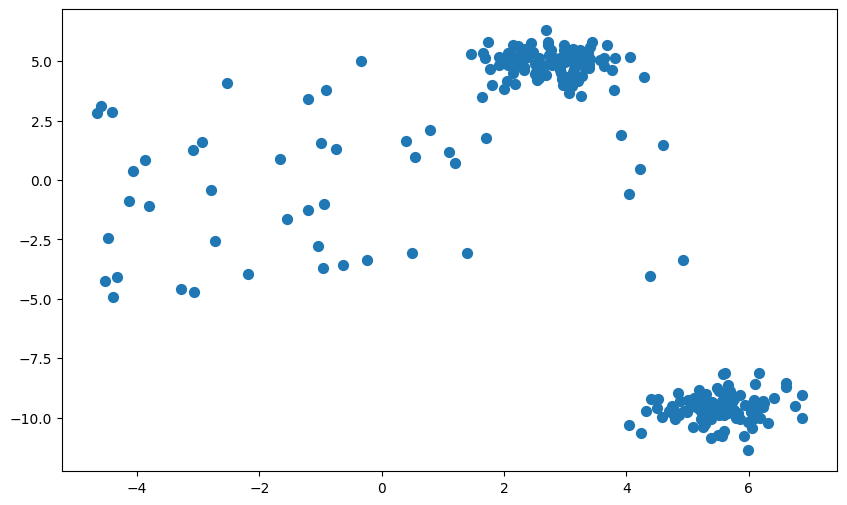

In [80]:
plt.figure(figsize=(10,6))
plt.scatter(x_dbscan_data[:,0], x_dbscan_data[:,1], s=50)

In [90]:
from sklearn.cluster import DBSCAN

dbscanmodel = DBSCAN(eps=1, min_samples=5)
yhat = dbscanmodel.fit_predict(x_dbscan_data)
print(yhat)

uniques, counts = np.unique(yhat, return_counts=True)
print(np.asarray((uniques, counts)))
print(np.asarray((uniques, counts)).T)
print(f'unique values : {uniques} and counts : {counts}')

[ 0  1  0  1  0  1  1  1  1  0  0  0  1  0  0  0  0  1  0  0  0  0  1  1
  1  0  0  1  1  0  1  0  1  1  0  1  0  1  1  0  1  0  1  0  1  0  1  0
  0  1  0  1  0  0  0  1  1  1  1  1  1  1  0  0  0  1  0  0  1  0  1  1
  0  0  1  0  1  0  1  0  1  1  0  1  1  1  1  1  0  0  0  1  0  0  0  0
  0  0  1  1  0  1  0  1  0  0  0  0  1  1  1  0  1  1  0  1  0  1  0  0
  1  0  1  0  1  1  1  1  0  1  0  1  0  0  1  1  0  0  0  1  0  1  0  0
  1  0  0  1  1  1  0  0  1  1  1  0  1  1  0  1  1  0  0  0  1  0  0  1
  1  1  1  0  0  1  0  1  1  0  0  0  1  0  1  0  0  0  1  0  0  0  1  1
  1  1  1  0  1  0  1  1 -1  2 -1 -1 -1  3 -1 -1  0  3 -1  0  3  2 -1 -1
 -1 -1 -1 -1 -1 -1 -1  2 -1  0 -1  3 -1  0 -1 -1 -1 -1 -1 -1 -1 -1  3 -1
  3 -1 -1 -1 -1 -1 -1  2  2 -1]
[[ -1   0   1   2   3]
 [ 35 104 100   5   6]]
[[ -1  35]
 [  0 104]
 [  1 100]
 [  2   5]
 [  3   6]]
unique values : [-1  0  1  2  3] and counts : [ 35 104 100   5   6]


- cluster 0, cluster 1 and -1 values are outliers

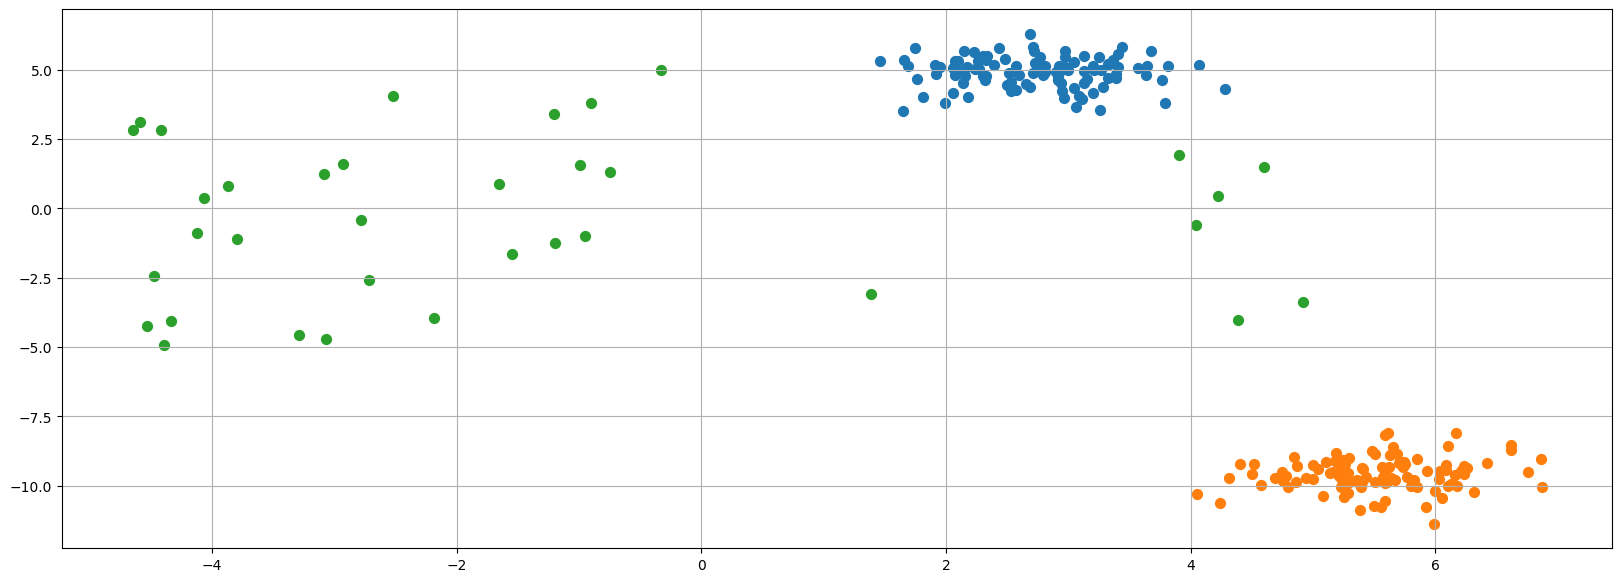

In [91]:
import scipy.cluster.hierarchy as sch



plt.figure(figsize=(20,7))
plt.scatter(x_dbscan_data[yhat==0,0], x_dbscan_data[yhat==0,1], s=50)
plt.scatter(x_dbscan_data[yhat==1,0], x_dbscan_data[yhat==1,1], s=50)
plt.scatter(x_dbscan_data[yhat==-1,0], x_dbscan_data[yhat==-1,1], s=50)

plt.grid(True)
plt.show()

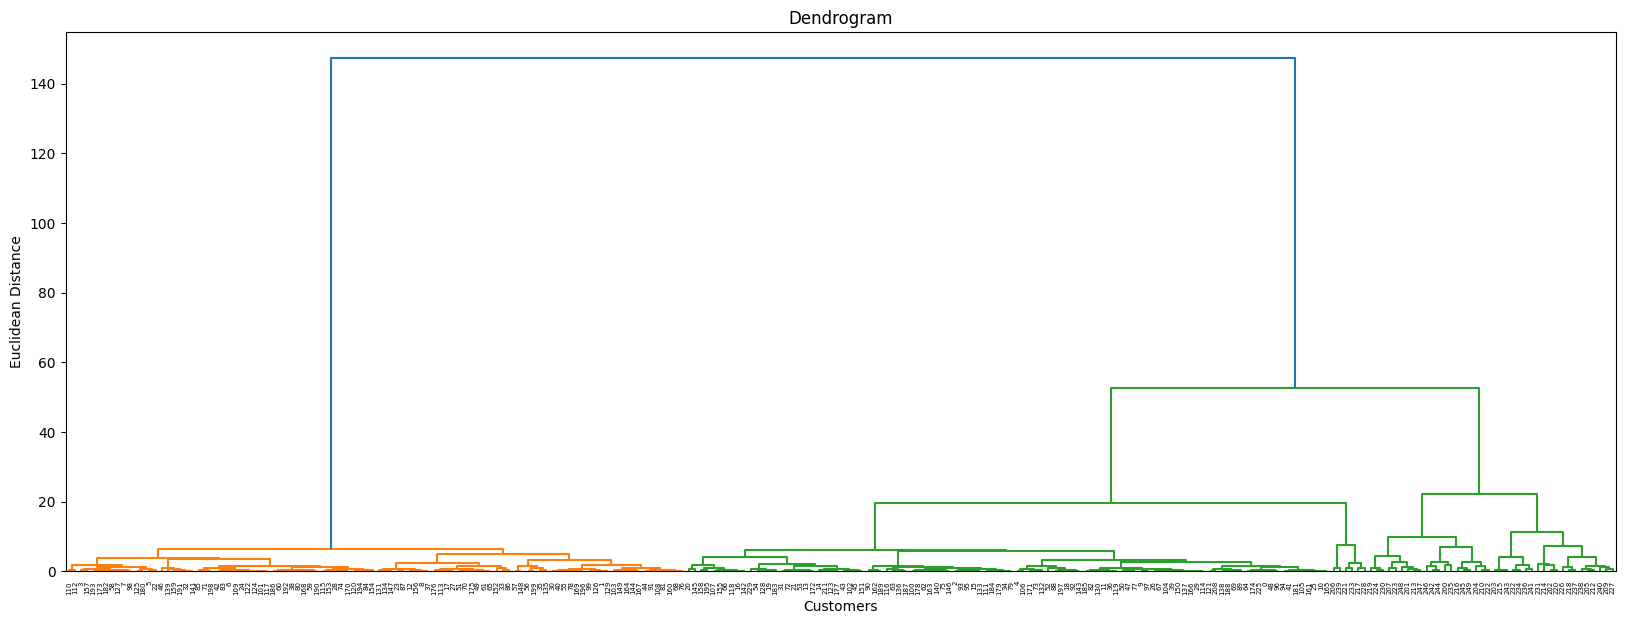

In [93]:
import scipy.cluster.hierarchy as sch

X = x_dbscan_data

plt.figure(figsize=(20,7))
dendogram = sch.dendrogram(sch.linkage(X, method = 'ward')) # Best method, incremental algorithm
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()